In [ ]:
import pandas as pd
print("Pandas is working fine")


In [9]:
import pandas as pd
df = pd.read_csv("../data/sample_emails.csv")
df.head()




,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal


In [11]:
df["label"].value_counts()

label
work          2
promotion     1
important     1
security      1
newsletter    1
personal      1
spam          1
Name: count, dtype: int64

In [3]:
import pandas as pd
import numpy as np
import re

# Load data
df = pd.read_csv("../data/sample_emails.csv")

# Quick look
print(df.shape)
print(df.columns)
df.head()


(8, 6)
Index(['id', 'sender', 'subject', 'body', 'priority', 'label'], dtype='object')


,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal


In [5]:
# Standardize column names if needed
df.columns = [c.strip().lower() for c in df.columns]

# Assume columns are named 'subject' and 'body'
SUBJECT_COL = 'subject'
BODY_COL = 'body'   # change to 'message' or whatever your CSV uses if needed

# Drop rows where both subject and body are missing
df = df.dropna(subset=[SUBJECT_COL, BODY_COL], how="all")

# Fill remaining NaNs in text columns with empty string
df[SUBJECT_COL] = df[SUBJECT_COL].fillna("")
df[BODY_COL] = df[BODY_COL].fillna("")


In [6]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    
    # Remove non-alphanumeric characters except basic punctuation
    text = re.sub(r"[^a-z0-9@.,!?'\s]", " ", text)
    
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["subject_clean"] = df[SUBJECT_COL].apply(clean_text)
df["body_clean"] = df[BODY_COL].apply(clean_text)

df[["subject", "subject_clean", "body", "body_clean"]].head()


,subject,subject_clean,body,body_clean
0,Offer Letter - Please Sign,offer letter please sign,"Dear Candidate, Congratulations! Please sign a...","dear candidate, congratulations! please sign a..."
1,Big Billion Sale is Live,big billion sale is live,Flat 70% OFF on electronics. Limited period of...,flat 70 off on electronics. limited period off...
2,Unusual Login Attempt,unusual login attempt,We detected a login attempt to your account fr...,we detected a login attempt to your account fr...
3,Weekly Tech Newsletter,weekly tech newsletter,"In this week's edition, learn about AI agents,...","in this week's edition, learn about ai agents,..."
4,Coffee this weekend?,coffee this weekend?,"Hey, long time no see! Are you free this weeke...","hey, long time no see! are you free this weeke..."


In [5]:
df["combined_text"] = (
    df["subject_clean"].fillna("") + " " + df["body_clean"].fillna("")
).str.strip()

df[["subject_clean", "body_clean", "combined_text"]].head()
print("Data loaded and initial processing done.")

NameError: name 'df' is not defined

In [6]:
import pandas as pd
df = pd.read_csv("../data/sample_emails.csv")   # or your file path


In [7]:
df['subject'] = df['subject'].fillna("")
df['body'] = df['body'].fillna("")
df['subject_clean'] = df['subject'].apply(clean_text)
df['body_clean'] = df['body'].apply(clean_text)


NameError: name 'clean_text' is not defined

In [ ]:
import pandas as pd
import re

# 1) Load the CSV and create df
df = pd.read_csv("../data/sample_emails.csv")

# 2) Handle missing values
df = df.dropna(subset=["subject", "body"], how="all")
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

# 3) DEFINE clean_text BEFORE using it
def clean_text(text):
    text = text.lower()                              # make lowercase
    text = re.sub(r"<.*?>", " ", text)               # remove HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)    # remove URLs
    text = re.sub(r"[^a-z0-9@.,!?'\s]", " ", text)   # remove weird symbols
    text = re.sub(r"\s+", " ", text).strip()         # fix extra spaces
    return text

# 4) Use clean_text to create cleaned columns
df["subject_clean"] = df["subject"].apply(clean_text)
df["body_clean"]   = df["body"].apply(clean_text)

# 5) Create combined text column (subject + body)
df["combined_text"] = df["subject_clean"] + " " + df["body_clean"]

df.head()



,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,offer letter please sign,"dear candidate, congratulations! please sign a...","offer letter please sign dear candidate, congr..."
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion,big billion sale is live,flat 70 off on electronics. limited period off...,big billion sale is live flat 70 off on electr...
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security,unusual login attempt,we detected a login attempt to your account fr...,unusual login attempt we detected a login atte...
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter,weekly tech newsletter,"in this week's edition, learn about ai agents,...","weekly tech newsletter in this week's edition,..."
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal,coffee this weekend?,"hey, long time no see! are you free this weeke...","coffee this weekend? hey, long time no see! ar..."


In [1]:
pip install nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 1.2 MB/s eta 0:00:01
   ------------- -------------------------- 0.5/1.5 MB 1.2 MB/s eta 0:00:01
   ------------- -------------------------- 0.5/1.5 MB 1.2 MB/s eta 0:00:01
   ------------- -------------------------- 0.5/1.5 MB 1.2 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.5 MB 541.6 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.5 MB 541.6 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.5 MB 541.6 kB/s eta 0:00:02
   --------------------------- ------------ 1.0/1.5 MB 503.5 kB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.5 MB 503.5 kB/s eta 0:00:01
   ---------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import nltk 
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words = [words for words in words if words not in stop_words]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\imuma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NameError: name 'words' is not defined

In [3]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter


In [4]:
df = pd.read_csv("../data/sample_emails.csv")


In [4]:
# 2. Create clean text column (subject + body → cleaned)
def basic_clean(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()                               
    text = re.sub(r"<.*?>", " ", text)              
    text = re.sub(r"http\S+|www\.\S+", " ", text)     
    text = re.sub(r"[^a-z0-9@.,!?'\s]", " ", text)    
    text = re.sub(r"\s+", " ", text).strip()          
    return text

In [5]:
# combine subject + body into one text column
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")
df["clean_text"] = df["text"].apply(basic_clean)


In [6]:
# 3. Remove stopwords using NLTK
stop_words = set(stopwords.words("english"))

def remove_stopwords(text: str) -> str:
    words = text.split()                      # simple tokenization
    filtered = [w for w in words if w not in stop_words]
    return " ".join(filtered)

df["clean_no_stop"] = df["clean_text"].apply(remove_stopwords)

# 4. Show first 3 rows
print("First 3 rows:")
print(df.head(3))

First 3 rows:
   id                sender                     subject  \
0   1        hr@company.com  Offer Letter - Please Sign   
1   2  noreply@shopping.com    Big Billion Sale is Live   
2   3     alerts@mybank.com       Unusual Login Attempt   

                                                body priority      label  \
0  Dear Candidate, Congratulations! Please sign a...     high  important   
1  Flat 70% OFF on electronics. Limited period of...      low  promotion   
2  We detected a login attempt to your account fr...     high   security   

                                                text  \
0  Offer Letter - Please Sign Dear Candidate, Con...   
1  Big Billion Sale is Live Flat 70% OFF on elect...   
2  Unusual Login Attempt We detected a login atte...   

                                          clean_text  \
0  offer letter please sign dear candidate, congr...   
1  big billion sale is live flat 70 off on electr...   
2  unusual login attempt we detected a login atte..

In [7]:
# 5. Analyze word frequency (using clean text without stopwords)
all_words = " ".join(df["clean_no_stop"]).split()
word_freq = Counter(all_words)

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

df = pd.read_csv("../data/sample_emails.csv")  # adjust path

def basic_clean(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9@.,!?'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")
df["clean_text"] = df["text"].apply(basic_clean)

# NLTK stopwords
# run this ONCE the first time:
# nltk.download("stopwords")
# nltk.download("punkt")

stop_words = set(stopwords.words("english"))


In [2]:
from nltk import word_tokenize
from nltk.probability import FreqDist

all_tokens = []

for text in df["clean_text"]:
    tokens = word_tokenize(text)                  # split into words
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    all_tokens.extend(tokens)

# Frequency distribution of all remaining words
fdist = FreqDist(all_tokens)

print("Top 20 keywords in the whole dataset:")
for word, freq in fdist.most_common(20):
    print(f"{word:15} {freq}")


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\imuma/nltk_data'
    - 'c:\\Users\\imuma\\AppData\\Local\\Programs\\Python\\Python312\\nltk_data'
    - 'c:\\Users\\imuma\\AppData\\Local\\Programs\\Python\\Python312\\share\\nltk_data'
    - 'c:\\Users\\imuma\\AppData\\Local\\Programs\\Python\\Python312\\lib\\nltk_data'
    - 'C:\\Users\\imuma\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [3]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\imuma\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [4]:
from nltk import word_tokenize
from nltk.probability import FreqDist

all_tokens = []

for text in df["clean_text"]:
    tokens = word_tokenize(text)                  # split into words
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    all_tokens.extend(tokens)

# Frequency distribution of all remaining words
fdist = FreqDist(all_tokens)

print("Top 20 keywords in the whole dataset:")
for word, freq in fdist.most_common(20):
    print(f"{word:15} {freq}")


Top 20 keywords in the whole dataset:
.               11
,               6
!               5
please          4
offer           3
letter          2
sign            2
today           2
login           2
attempt         2
coffee          2
weekend         2
?               2
share           2
project         2
update          2
mandatory       2
training        2
dear            1
candidate       1


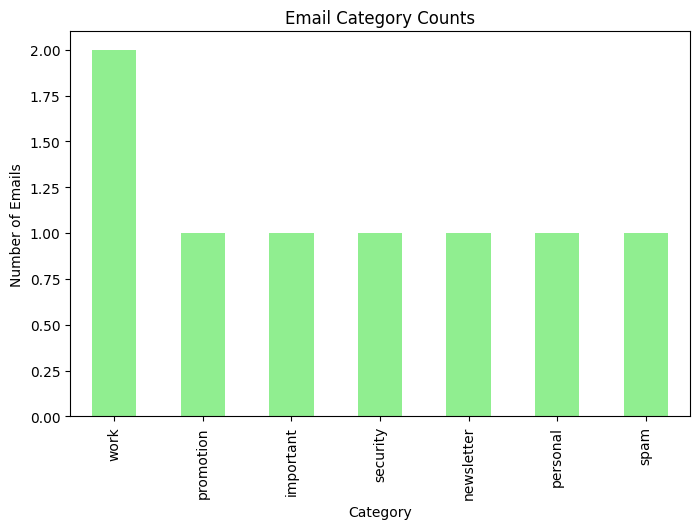

In [ ]:
# Visualize Category Counts (Bar Chart)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["label"].value_counts().plot(kind="bar", color="lightgreen")
plt.title("Email Category Counts")
plt.xlabel("Category")
plt.ylabel("Number of Emails")
plt.show()


 Category: spam
Chosen because detecting harmful or fraudulent emails is essential for safety.

Rule detects spam‑related words such as “win,” “click,” “offer,” “prize,” “you won,” “congratulations,” etc.

 Category: promotion
Promotions often clutter inboxes but are not harmful; separating them improves inbox clarity.

Detected using marketing words like “sale,” “discount,” “flat 70%,” “offer,” “limited period,” etc.

 Category: important
Important emails require priority attention.

The rule detects formal HR or organization keywords like “offer letter,” “candidate,” “congratulations,” etc.

 Category: security
Security incidents (e.g., login attempts) must be highlighted.

Detected using words like “unusual login,” “verify,” “account,” “security alert.”

 Category: newsletter
Newsletters are informational but not urgent.

Detected using words like “weekly tech,” “edition,” “newsletter,” “learn about.”

 Category: personal
Personal conversations should be identified separately from work emails.

Rule detects friendly tone: “hey,” “long time,” “weekend,” “coffee.”

 Category: work
Work emails must be separated for productivity.

Detected using formal task‑related words like “project,” “meeting,” “reminder,” “update.”



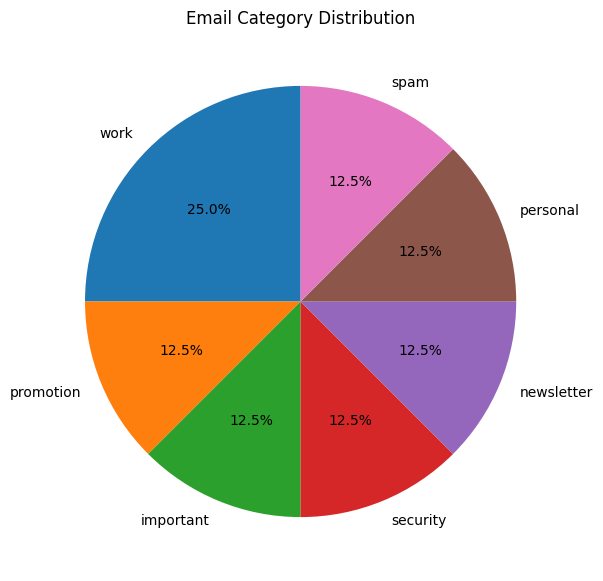

In [6]:
plt.figure(figsize=(7,7))
df["label"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Email Category Distribution")
plt.ylabel("")
plt.show()


In [7]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words("english"))

def top_keywords_per_category(category):
    texts = df[df["label"] == category]["clean_text"]
    words = []
    for t in texts:
        tokens = word_tokenize(str(t).lower())
        tokens = [w for w in tokens if w.isalpha() and w not in stop_words]
        words.extend(tokens)
    return Counter(words).most_common(5)

categories = df["label"].unique()

for c in categories:
    print(f"\nTop keywords in {c}:")
    print(top_keywords_per_category(c))



Top keywords in important:


KeyError: 'clean_text'

In [11]:
print(df.columns.tolist())
print(df.head(3).T)   # transpose to see small table vertically


['id', 'sender', 'subject', 'body', 'priority', 'label']
                                                          0  \
id                                                        1   
sender                                       hr@company.com   
subject                          Offer Letter - Please Sign   
body      Dear Candidate, Congratulations! Please sign a...   
priority                                               high   
label                                             important   

                                                          1  \
id                                                        2   
sender                                 noreply@shopping.com   
subject                            Big Billion Sale is Live   
body      Flat 70% OFF on electronics. Limited period of...   
priority                                                low   
label                                             promotion   

                                                          2

In [12]:
# 2) Ensure subject/body exist and fill missing
for col in ["subject","body"]:
    if col not in df.columns:
        raise KeyError(f"Expected column '{col}' not found in CSV. Columns available: {df.columns.tolist()}")
    df[col] = df[col].fillna("")

# 3) Basic cleaning function (always define before use)
def basic_clean(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)               # remove HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)    # remove URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)         # keep only letters & numbers & spaces
    text = re.sub(r"\s+", " ", text).strip()         # collapse spaces
    return text

# 4) Create or overwrite clean_text column (subject + body)
df["text"] = df["subject"].astype(str) + " " + df["body"].astype(str)
df["clean_text"] = df["text"].apply(basic_clean)

# Confirm creation
print("'clean_text' created. Sample:")
print(df[["subject","clean_text"]].head(3))

'clean_text' created. Sample:
                      subject  \
0  Offer Letter - Please Sign   
1    Big Billion Sale is Live   
2       Unusual Login Attempt   

                                          clean_text  
0  offer letter please sign dear candidate congra...  
1  big billion sale is live flat 70 off on electr...  
2  unusual login attempt we detected a login atte...  


In [13]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words("english"))

def top_keywords_per_category(category):
    texts = df[df["label"] == category]["clean_text"]
    words = []
    for t in texts:
        tokens = word_tokenize(str(t).lower())
        tokens = [w for w in tokens if w.isalpha() and w not in stop_words]
        words.extend(tokens)
    return Counter(words).most_common(5)

categories = df["label"].unique()

for c in categories:
    print(f"\nTop keywords in {c}:")
    print(top_keywords_per_category(c))



Top keywords in important:
[('offer', 2), ('letter', 2), ('please', 2), ('sign', 2), ('dear', 1)]

Top keywords in promotion:
[('big', 1), ('billion', 1), ('sale', 1), ('live', 1), ('flat', 1)]

Top keywords in security:
[('login', 2), ('attempt', 2), ('unusual', 1), ('detected', 1), ('account', 1)]

Top keywords in newsletter:
[('weekly', 1), ('tech', 1), ('newsletter', 1), ('week', 1), ('edition', 1)]

Top keywords in personal:
[('coffee', 2), ('weekend', 2), ('hey', 1), ('long', 1), ('time', 1)]

Top keywords in spam:
[('click', 1), ('claim', 1), ('lottery', 1), ('share', 1), ('anyone', 1)]

Top keywords in work:
[('project', 2), ('update', 2), ('mandatory', 2), ('training', 2), ('required', 1)]


In [15]:
df["is_spam"] = df["clean_text"].str.contains("win|click|offer", case=False)
df["is_promotion"] = df["clean_text"].str.contains("sale|discount|offer", case=False)
df["is_urgent"] = df["clean_text"].str.contains("immediately|urgent|important", case=False)
df["is_security"] = df["clean_text"].str.contains("login|account|verify", case=False)


In [16]:
rule_cols = ["is_spam", "is_promotion", "is_urgent", "is_security"]
df["multi_match"] = df[rule_cols].sum(axis=1)

df[df["multi_match"] >= 2]


,id,sender,subject,body,priority,label,text,clean_text,is_spam,is_promotion,is_urgent,is_security,multi_match
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,"Offer Letter - Please Sign Dear Candidate, Con...",offer letter please sign dear candidate congra...,True,True,False,False,2
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion,Big Billion Sale is Live Flat 70% OFF on elect...,big billion sale is live flat 70 off on electr...,True,True,False,False,2
